# Week 10 extension — train + evaluate (notebook 10d)

This notebook merges the **training** half (Week 10's Tasks 60–66, formerly
in `10d_extend_and_train.ipynb`) and the **evaluation** half (Tasks 67–70,
formerly in `10e_diffusion_NLL_ablations.ipynb`) into a single Colab-friendly
file. Each Colab session is isolated, so doing both halves in one notebook
means a fresh runtime can pick up where you left off without re-running
setup twice and without risking the `EXPERIMENTS` dict drifting between the
two halves.

## How to use this notebook

There is **one flag at the top** that determines what the notebook does:

- `MODE = "train"` — runs the data-augmentation cells (Tasks 60–63), the
  experiment-menu setup (Tasks 64–65), the training loop (Task 66), and the
  visual sanity check. The training loop is **idempotent**: it skips any
  experiment whose `ckpt_<name>.ckpt` already exists. Run the notebook many
  times with one new entry enabled in `ENABLED_EXPERIMENTS` per session.
- `MODE = "eval"` — skips training, jumps into the NLL ablation pipeline
  (Tasks 67–69), and scores every `ckpt_E*.ckpt` it finds in this directory.

**Recipe:** run with `MODE = "train"` repeatedly (one new experiment per
session) until you have all the checkpoints you want, then flip to
`MODE = "eval"` and run the notebook once to score them.

[**↓ Jump to evaluation (Tasks 67–70)**](#eval-mode)

> The **test split is reserved for the PI**. Every data-loading cell in this
> notebook filters to `split in {"train", "val"}`. Do not change that.


In [36]:
MODE = "eval"   # set to "eval" once you have ckpt_E*.ckpt files to score

assert MODE in ("train", "eval"), f"MODE must be 'train' or 'eval', got {MODE!r}"
TRAIN_MODE = (MODE == "train")
EVAL_MODE  = (MODE == "eval")
print(f"MODE = {MODE!r}  (TRAIN_MODE={TRAIN_MODE}, EVAL_MODE={EVAL_MODE})")


MODE = 'eval'  (TRAIN_MODE=False, EVAL_MODE=True)


In [23]:
# Standard Week 10 setup: locate the repo, install if missing.

import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


git pull skipped: Command '['git', '-C', '../../', 'pull']' returned non-zero exit status 128.


ModuleNotFoundError: No module named 'infrastructure'

In [24]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, json, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# Bootstrap sys.path and locate artifacts.
import os, sys

for _p in [os.path.abspath(os.path.join(repo_path, "weeks", "week_10")),
           os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from conditioned_infrastructure import find_week10_artifacts
# parquet_v2 is built fresh in Part A every run; raw CSV is needed by the
# eval phase (Task 67 Part 1). Both are listed as required so a missing
# raw CSV fails loudly at setup time rather than at Task 67.
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
print(f"using conditioned_infrastructure from: {paths['conditioned_py']}")

from unconditioned_infrastructure import make_cosine_schedule
from conditioned_infrastructure import (
    ExtendedConditionalResidualDataset,
    ExtendedConditionalDiffusionLightning,
    train_experiment,
    load_trained_experiment,
    sample_conditional_extended,
    build_model,
    block_cond_concat,
    k_run_combined,
    discover_experiment_checkpoints,
)
from butterflAI_model import ButterflAIModel

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR

classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the v1 parquet — we extend it but never modify it.
# Test split is reserved for the PI.
windows_v1 = pd.read_parquet(paths["parquet_v1"])
windows_v1 = windows_v1.loc[windows_v1["split"].isin(["train", "val"])].reset_index(drop=True)
print(f"v1 parquet (train+val only): {len(windows_v1)} rows")
print(f"  splits: {windows_v1['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles: {sorted(windows_v1['cycle'].unique())}")
print(f"v2 parquet target: {PARQUET_V2}")
print(f"device           : {device}")


using conditioned_infrastructure from: c:\Users\larsg\Downloads\week_10\conditioned_infrastructure.py
v1 parquet (train+val only): 287 rows
  splits: {'train': 232, 'val': 55}
  cycles: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
v2 parquet target: c:\Users\larsg\Downloads\week_10\diffusion_windows_v2.parquet
device           : cpu


---
## Part A — Build the augmented parquet

We're going to add three families of new conditioning columns to the
v1 parquet:

1. **Cycle and hemisphere identifiers** — a normalized cycle number and
   a north/south indicator.
2. **Opposite-hemisphere summaries** — for each window, the
   *contemporaneous* opposite-hemisphere activity. This is not leakage:
   contemporaneous opposite-hemisphere activity is operationally
   observable (an operational forecaster on the day of the same window
   would have it).
3. **Smoothed-area trajectory** — the past `K` windows of `area_smoothed`
   for the same hemicycle, as a short autoregressive history.

The build cells **rewrite `diffusion_windows_v2.parquet` every run**. We
deliberately do *not* gate on file existence — if you change how a
column is computed and don't see the change downstream, the most
common explanation is "the file was cached." We avoid that failure
mode by always rewriting.


---
## Task 60 — Cycle and hemisphere identifiers

Add two new columns to the dataframe:

- `cycle_norm`: cycle number rescaled to roughly `[-1, +1]` over the
  train range. The point of normalization is not to be exactly in
  `[-1, +1]` — it's to put the input on the same numerical scale as the
  other conditioning vectors so the network doesn't have to learn an
  outsized weight for it.
- `hemi_id`: `+1` for north, `-1` for south.

Both are cheap and let downstream experiments test whether
*structural* per-cycle / per-hemisphere effects survive once amplitude
is controlled for.


In [26]:
# Task 60 — add cycle_norm and hemi_id.

windows_aug = windows_v1.copy()

# TODO: compute cycle_norm. Use train-set cycle range so this is well
# defined for both splits. Aim for the train cycle range to map roughly
# onto [-1, +1].
_train_cycles = windows_aug.loc[windows_aug["split"] == "train", "cycle"]
_cmin, _cmax  = _train_cycles.min(), _train_cycles.max()
windows_aug["cycle_norm"] = 2.0 * (windows_aug["cycle"] - _cmin) / (_cmax - _cmin) - 1.0

# TODO: compute hemi_id. +1 north, -1 south.
windows_aug["hemi_id"] = np.where(windows_aug["hemisphere"] == "north", 1.0, -1.0)

print("cycle_norm range:", windows_aug["cycle_norm"].min(), windows_aug["cycle_norm"].max())
print("hemi_id values  :", windows_aug["hemi_id"].unique())


cycle_norm range: -1.0 1.0
hemi_id values  : [-1.  1.]


---
## Task 61 — Opposite-hemisphere conditioning

For each window in hemisphere *h* at time `tau_center`, attach the
contemporaneous opposite-hemisphere activity summary:

- `opp_area_smoothed` — opposite hemisphere's `area_smoothed`
- `opp_mu_universal`  — opposite hemisphere's `mu_universal`
- `opp_amplitude`     — opposite hemisphere's `amplitude`
- `opp_valid`         — 1 if a matching opposite row was found at the
  same `(cycle, tau_center)`, else 0.

When `opp_valid == 0` (no matching opposite row), impute with the
**train-set mean** of each opposite-* column. This way the network always
sees a defined input; downstream you can decide whether to gate on the
mask.

**Implementation hint:** the cleanest way is a self-merge of the
dataframe with itself: produce a "right side" with `hemisphere`
flipped and renamed columns, then merge on `(cycle, tau_center)`.


In [27]:
# Task 61 - attach contemporaneous opposite-hemisphere summaries.
#
# tau_center is cycle-relative, and north/south cycles start at different
# calendar dates, so the same calendar moment has *different* tau_center
# values in each hemisphere.  We must match on calendar year instead.

_flip = {"north": "south", "south": "north"}

# Build a per-row calendar year: year_center = tau_center + t0(cycle, hemi)
_t0_map = {(int(c), str(h)): float(classical.lookup_t0(int(c), h))
           for (c, h) in classical.known_hemicycles()}

windows_aug["_year_center"] = windows_aug.apply(
    lambda r: r["tau_center"] + _t0_map.get((int(r["cycle"]), str(r["hemisphere"])), np.nan),
    axis=1,
)

# Build the right side: flip hemisphere, rename opp_ columns, keep year_center as key.
_right = (windows_aug
          .loc[:, ["cycle", "_year_center", "hemisphere",
                   "area_smoothed", "mu_universal", "amplitude"]]
          .assign(hemisphere=lambda d: d["hemisphere"].map(_flip))
          .rename(columns={
              "area_smoothed": "opp_area_smoothed",
              "mu_universal":  "opp_mu_universal",
              "amplitude":     "opp_amplitude",
          }))

# Merge on calendar year so contemporaneous windows match across hemispheres.
windows_aug = windows_aug.merge(
    _right, on=["cycle", "_year_center", "hemisphere"],
    how="left", indicator="_opp_match",
)
windows_aug["opp_valid"] = (windows_aug["_opp_match"] == "both").astype(np.float32)
windows_aug = windows_aug.drop(columns=["_opp_match", "_year_center"])

# Impute missing opp_* values with train-set means.
_opp_cols = ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"]
_train_mask = (windows_aug["split"] == "train") & (windows_aug["opp_valid"] == 1.0)
for _c in _opp_cols:
    _mean = windows_aug.loc[_train_mask, _c].mean()
    windows_aug[_c] = windows_aug[_c].fillna(_mean)

print(f"opp_valid coverage: {windows_aug['opp_valid'].mean():.3f}")
print(f"opp_area_smoothed (train, valid): "
      f"mean={windows_aug.loc[_train_mask, 'opp_area_smoothed'].mean():.3f}, "
      f"std={windows_aug.loc[_train_mask, 'opp_area_smoothed'].std():.3f}")


opp_valid coverage: 0.648
opp_area_smoothed (train, valid): mean=96.913, std=42.818


---
## Task 62 — Smoothed-area trajectory (cycle history)

For each window, attach the previous `K` values of `area_smoothed`
from the same hemicycle (same `cycle` AND same `hemisphere`), ordered
chronologically by `tau_center`. Columns: `area_lag1`, `area_lag2`, …,
`area_lagK`.

`area_lag1` is the *previous* window's smoothed area; `area_lagK` is
the one K steps back. Boundary windows (near the start of a hemicycle,
where fewer than K prior windows exist) get train-set-mean imputation
and a `traj_valid` column set to 0 for that row.

The point: cycle *history* is information that amplitude alone misses.
A window 6 months into a strong cycle and a window 6 months from the
end of a strong cycle have similar amplitude but very different
trajectory.

**Implementation hint:** sort within each hemicycle by `tau_center`,
then shift the `area_smoothed` series by 1, 2, …, K.


In [28]:
# Task 62 — attach the smoothed-area trajectory (K lagged values).

K_LAGS = 4

# TODO: within each (cycle, hemisphere) group, sort by tau_center and
#       produce K columns of shifted area_smoothed.
_sorted = windows_aug.sort_values(["cycle", "hemisphere", "tau_center"])

_lag_cols = [f"area_lag{k}" for k in range(1, K_LAGS + 1)]
for k, col in enumerate(_lag_cols, start=1):
    _sorted[col] = _sorted.groupby(["cycle", "hemisphere"])["area_smoothed"].shift(k)

# A row is traj_valid iff *all* K lags exist.
_sorted["traj_valid"] = (~_sorted[_lag_cols].isna().any(axis=1)).astype(np.float32)

# TODO: impute boundary NaNs with train-set means.
_train_mask = (_sorted["split"] == "train") & (_sorted["traj_valid"] == 1.0)
for col in _lag_cols:
    _mean = _sorted.loc[_train_mask, col].mean()
    _sorted[col] = _sorted[col].fillna(_mean)

windows_aug = _sorted.sort_index()  # restore original row order

print(f"traj_valid coverage: {windows_aug['traj_valid'].mean():.3f}")
print(f"lag columns: {_lag_cols}")


traj_valid coverage: 0.721
lag columns: ['area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


In [29]:
# Cycle-phase encoding: sin/cos of tau_center normalised by a nominal
# 11-year cycle period. Together they uniquely identify where in the
# cycle a window sits while keeping the representation smooth and bounded.
T_NOMINAL = 11.0
windows_aug["sin_tau"] = np.sin(2 * np.pi * windows_aug["tau_center"] / T_NOMINAL).astype(np.float32)
windows_aug["cos_tau"] = np.cos(2 * np.pi * windows_aug["tau_center"] / T_NOMINAL).astype(np.float32)

print(f"sin_tau : mean={windows_aug['sin_tau'].mean():.3f}, std={windows_aug['sin_tau'].std():.3f}")
print(f"cos_tau : mean={windows_aug['cos_tau'].mean():.3f}, std={windows_aug['cos_tau'].std():.3f}")


sin_tau : mean=0.226, std=0.684
cos_tau : mean=0.318, std=0.619


---
## Task 63 — Write `diffusion_windows_v2.parquet` and sanity-check

Write the augmented dataframe. Sanity checks before we trust it
downstream:

- Row count unchanged from v1 (we did not gain or lose any windows).
- Every original v1 column is preserved bit-for-bit.
- New cond columns are finite **wherever the validity mask says they
  should be**.
- `split` column is unchanged.


In [30]:
# Task 63 — write v2 + sanity checks.

# Sanity 1: row count.
assert len(windows_aug) == len(windows_v1), \
    f"row count drifted: {len(windows_aug)} vs v1 {len(windows_v1)}"

# Sanity 2: every v1 column preserved bit-for-bit.
for c in windows_v1.columns:
    assert c in windows_aug.columns, f"missing v1 column {c}"
    if windows_v1[c].dtype.kind in "fc":
        assert np.allclose(windows_v1[c].to_numpy(),
                           windows_aug[c].to_numpy(), equal_nan=True), c
    else:
        assert (windows_v1[c].astype(str).to_numpy()
                == windows_aug[c].astype(str).to_numpy()).all(), c

# Sanity 3: new columns finite where the validity masks allow.
NEW_COND_COLS = ["cycle_norm", "hemi_id",
                 "opp_area_smoothed", "opp_mu_universal", "opp_amplitude",
                 *[f"area_lag{k}" for k in range(1, K_LAGS + 1)],
                 "sin_tau", "cos_tau"]
for c in NEW_COND_COLS:
    assert windows_aug[c].notna().all(), f"NaN remains in {c}"

# Sanity 4: split column unchanged.
assert (windows_aug["split"].to_numpy() == windows_v1["split"].to_numpy()).all()

# Always rewrite. Never cache.
windows_aug.to_parquet(PARQUET_V2, index=False)
print(f"wrote {PARQUET_V2}  ({len(windows_aug)} rows, {len(windows_aug.columns)} cols)")
print(f"new cond columns: {NEW_COND_COLS}")


wrote c:\Users\larsg\Downloads\week_10\diffusion_windows_v2.parquet  (287 rows, 51 cols)
new cond columns: ['cycle_norm', 'hemi_id', 'opp_area_smoothed', 'opp_mu_universal', 'opp_amplitude', 'area_lag1', 'area_lag2', 'area_lag3', 'area_lag4', 'sin_tau', 'cos_tau']


In [31]:
print(pd.read_parquet(PARQUET_V2).columns)

Index(['cycle', 'hemisphere', 'amplitude', 'tau_center', 'mu_universal',
       'model_sigma', 'area_smoothed', 'hist_emp_00', 'hist_par_00',
       'hist_emp_01', 'hist_par_01', 'hist_emp_02', 'hist_par_02',
       'hist_emp_03', 'hist_par_03', 'hist_emp_04', 'hist_par_04',
       'hist_emp_05', 'hist_par_05', 'hist_emp_06', 'hist_par_06',
       'hist_emp_07', 'hist_par_07', 'hist_emp_08', 'hist_par_08',
       'hist_emp_09', 'hist_par_09', 'hist_emp_10', 'hist_par_10',
       'hist_emp_11', 'hist_par_11', 'hist_emp_12', 'hist_par_12',
       'hist_emp_13', 'hist_par_13', 'hist_emp_14', 'hist_par_14', 'split',
       'cycle_norm', 'hemi_id', 'opp_area_smoothed', 'opp_mu_universal',
       'opp_amplitude', 'opp_valid', 'area_lag1', 'area_lag2', 'area_lag3',
       'area_lag4', 'traj_valid', 'sin_tau', 'cos_tau'],
      dtype='object')


---
## Part B — wandb setup and the experiment menu

### Task 64 — Per-student wandb project

Each student gets their **own** wandb project. Replace the placeholder
strings below with your handle. Every training run in this notebook
logs to that project with the experiment ID as the run name; you can
compare all your variants on a single dashboard.

If wandb is unavailable in your environment, training will fall back to
a local CSV logger automatically. The assertion guard runs in both
modes so eval mode also tells you if you forgot to personalize the
project name.


In [32]:
# Task 64 — wandb identity. Fall back to CSV logging if wandb unavailable.

WANDB_PROJECT = "butterflai-w10ext-lcampsteijn"
WANDB_ENTITY  = None      # set to your wandb username if using teams

# Verify that the placeholder has been replaced (allow None entity).
assert "your-handle" not in WANDB_PROJECT, \
    "Set WANDB_PROJECT to your own project name before training."


### Task 65 — Design your own experiments

The Week 10 baseline (E0) reproduces the existing conditional
diffusion on the v2 parquet — no new knobs. Everything beyond it is
your call. Each variant you propose should change **one knob** from
the previous run and answer **one question**.

The knobs available are:

- **Cond groups** (`groups` / `consumed_keys`): `base`, plus any of
  `cyclehemi`, `opp`, `traj`.
- **Architecture** (`arch`): `concat` or `film`.
- **Classifier-free guidance**: `cond_dropout_p=0.1` at training time;
  10e sweeps the guidance weight at sampling.
- **Fourier lifting**: `fourier=True` lifts cond scalars via sin/cos.

The menu below escalates roughly by effort-per-insight. Pick what's
interesting, add a new entry to `EXPERIMENTS`, and progress one
variant per session.

**Level 1 — same cond, change the channel.**
Add one of the new cond groups (`cyclehemi`, `opp`, `traj`) to E0's
`consumed_keys`. *Does the diffusion's val NLL drop when given more
information, with the architecture held fixed?*

**Level 2 — same information, change the mechanism.**
Switch `arch` from `concat` to `film` while keeping `cond_base` only.
*Does the modulation mechanism alone close the gap with classical?*

**Level 3 — best information × best mechanism.**
Combine your best Level 1 cond set with FiLM. *Is the combined gain
additive, or did Level 2 already capture it?*

**Level 4 — guidance.**
Set `cond_dropout_p=0.1` and train. Sampling guidance is swept in 10e.
*Can sharpening the conditional density buy you margin over Level 3?*

**Level 5 — Fourier lifting.**
Set `fourier=True`. *Does sin/cos lifting of the cond scalars help the
network represent boundaries?*

You can go further — bump `hidden_dim` / `n_layers`, raise `K_LAGS`
back in Task 62, pair lagged opposite-hemisphere with trajectory, or
anything else you can defend. Different students should diverge here;
results pool in 10e.

In [33]:
# Task 65 — experiment specs. Start with the baseline; add new entries
# below as you escalate (see the markdown above). See
# conditioned_infrastructure.build_model for the recognized keys.

_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     20000,
    "lr":             1e-3,
    "batch_size":     64,
}

def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

EXPERIMENTS = {
    "E0": _spec(),   # baseline — same 4-D cond on the v2 parquet
    "E1": _spec(                         # + sin/cos cycle-phase encoding
        consumed_keys=["cond_base", "cond_timing"],
        groups=["base", "timing"],
    ),
    "E2": _spec(                         # Level 1: + cycle/hemi identifiers
        consumed_keys=["cond_base", "cond_cyclehemi"],
        groups=["base", "cyclehemi"],
    ),
    "E3": _spec(                         # Level 1: + opposite hemisphere
        consumed_keys=["cond_base", "cond_opp"],
        groups=["base", "opp"],
    ),
    "E4": _spec(                         # Level 1: + trajectory lags
        consumed_keys=["cond_base", "cond_traj"],
        groups=["base", "traj"],
    ),
    "E5": _spec(arch="film"),            # Level 2: FiLM arch, base cond only
    "E6": _spec(                         # CFG-ready E4: traj + dropout
        consumed_keys=["cond_base", "cond_traj"],
        groups=["base", "traj"],
        cond_dropout_p=0.10,
    ),
    "E7": _spec(                         # combine best signals: timing + traj
        consumed_keys=["cond_base", "cond_timing", "cond_traj"],
        groups=["base", "timing", "traj"],
    ),
    "E8": _spec(                         # FiLM revisit: smaller net
        arch="film",
        hidden_dim=64,
        n_layers=2,
    ),
    "E9": _spec(                        # E4 + more capacity
        consumed_keys=["cond_base", "cond_traj"],
        groups=["base", "traj"],
        hidden_dim=256,
        n_layers=5,
    ),
    "E10": _spec(                       # E4 + Fourier expansion of cond scalars
        consumed_keys=["cond_base", "cond_traj"],
        groups=["base", "traj"],
        fourier=True,
        fourier_max_freq=1.5,
    ),
    "E11": _spec(                       # E4 + small-data regularization
        consumed_keys=["cond_base", "cond_traj"],
        groups=["base", "traj"],
        hidden_dim=64, n_layers=2,
        batch_size=128, lr=5e-4,
    ),
    "E12": _spec(                       # gentler CFG on E4 conditioning
        consumed_keys=["cond_base", "cond_traj"],
        groups=["base", "traj"],
        cond_dropout_p=0.05,
    ),
    "E4_ema": _spec(                       # EMA validation: E4 + EMA weights
        consumed_keys=["cond_base", "cond_traj"],
        groups=["base", "traj"],
        ema_decay=0.999,
    ),
    "E13": _spec(                       # EMA validation: E4 + EMA weights
        arch = "film",
        cond_dropout_p = 0.1,
    ),
    "E14": _spec(                       # EMA validation: E4 + EMA weights
        arch = "film",
    ),
    # Add your own variants below, e.g.:
    #   "E1": _spec(consumed_keys=["cond_base", "cond_opp"],
    #               groups=["base", "opp"]),
    #   "E2": _spec(arch="film"),
}

for name, cfg in EXPERIMENTS.items():
    print(f"{name}: arch={cfg['arch']:6s}  consumed={cfg['consumed_keys']}  "
          f"fourier={cfg['fourier']}  cond_dropout_p={cfg['cond_dropout_p']}")

E0: arch=concat  consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E1: arch=concat  consumed=['cond_base', 'cond_timing']  fourier=False  cond_dropout_p=0.0
E2: arch=concat  consumed=['cond_base', 'cond_cyclehemi']  fourier=False  cond_dropout_p=0.0
E3: arch=concat  consumed=['cond_base', 'cond_opp']  fourier=False  cond_dropout_p=0.0
E4: arch=concat  consumed=['cond_base', 'cond_traj']  fourier=False  cond_dropout_p=0.0
E5: arch=film    consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E6: arch=concat  consumed=['cond_base', 'cond_traj']  fourier=False  cond_dropout_p=0.1
E7: arch=concat  consumed=['cond_base', 'cond_timing', 'cond_traj']  fourier=False  cond_dropout_p=0.0
E8: arch=film    consumed=['cond_base']  fourier=False  cond_dropout_p=0.0
E9: arch=concat  consumed=['cond_base', 'cond_traj']  fourier=False  cond_dropout_p=0.0
E10: arch=concat  consumed=['cond_base', 'cond_traj']  fourier=True  cond_dropout_p=0.0
E11: arch=concat  consumed=['cond_base', 'cond_tra

---
## Part C — Disciplined sweep (TRAIN MODE)

### Task 66 — Enable a subset and train

Discipline:

- Add at most **one new experiment per session** beyond the baseline.
  Two-knob-at-a-time changes make the 10e diff impossible to read.
- Each enabled experiment logs to your wandb project under its name
  (`E0`, `E1`, …); compare them on a single dashboard.
- The loop skips checkpoints that already exist on disk, so re-running
  the notebook does not retrain unless you delete the file.

*The cells below only execute when `MODE == "train"`.*


In [34]:
if not TRAIN_MODE:
    print("Skipping Task 66 training loop (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Task 66 — enable, then train. EDIT THIS LIST.

    ENABLED_EXPERIMENTS = ["E0", "E1", "E2", "E3", "E4", "E5", "E6", "E7", "E8", "E9", "E10", "E4_ema", "E13", "E14"]   # add one experiment per session

    for _name in ENABLED_EXPERIMENTS:
        if _name not in EXPERIMENTS:
            raise KeyError(f"unknown experiment {_name!r}; defined: {list(EXPERIMENTS)}")
        train_experiment(
            name=_name, cfg=EXPERIMENTS[_name],
            windows_aug=windows_aug, ckpt_dir=CKPT_DIR,
            wandb_project=WANDB_PROJECT, wandb_entity=WANDB_ENTITY,
            alpha_np=alpha_np, sigma_np=sigma_np, T=T,
            bin_centers=BIN_CENTERS, bin_width=BIN_WIDTH,
        )


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[E0] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E0.ckpt; skipping training.
[E1] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E1.ckpt; skipping training.
[E2] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E2.ckpt; skipping training.
[E3] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E3.ckpt; skipping training.
[E4] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E4.ckpt; skipping training.
[E5] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E5.ckpt; skipping training.
[E6] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E6.ckpt; skipping training.
[E7] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E7.ckpt; skipping training.
[E8] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E8.ckpt; skipping training.
[E9] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E9.ckpt; skipping training.
[E10] checkpoint exists at c:\Users\larsg\Downloads\week_10\ckpt_E10.ckpt; skipp

c:\Users\larsg\anaconda3_new\envs\fresh_env\lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\larsg\Downloads\week_10 exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\larsg\anaconda3_new\envs\fresh_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\larsg\anaconda3_new\envs\fresh_env\lib\site-packages\pytorch_lightning\loops\fit_loop.py:321: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.

  | Name         | Type                        | Params | Mode  | FLOPs
------------------------------------------------

epoch,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇████
eval/end_of_training,▁
sample_cov_frob,█▁▁▁
sample_std_mse,█▁▁▁
train_loss,█▂▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▂▂▁▁▂▁▂▂▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇██
val_loss,█▆▂▃▁▃▁▁▂▁▂▁▁▁▂▂▁▁▂▂▃▁▃▄▂▂▂▂▂▃▄▃▂▃▄▃▃▂▃▃
val_sample_cov_frob,█▁▁▁
val_sample_std_mse,█▁▁▁
epoch,754
eval/end_of_training,755


[E14] saved c:\Users\larsg\Downloads\week_10\ckpt_E14.ckpt


---
## Part D — Visual sanity check on the most recent training

Sample a small batch of validation conditioning vectors and overlay
the diffusion's generated residuals against the ground truth. This is
a "did training collapse?" check — not a quantitative comparison. The
real evaluation lives in the EVAL MODE section below.


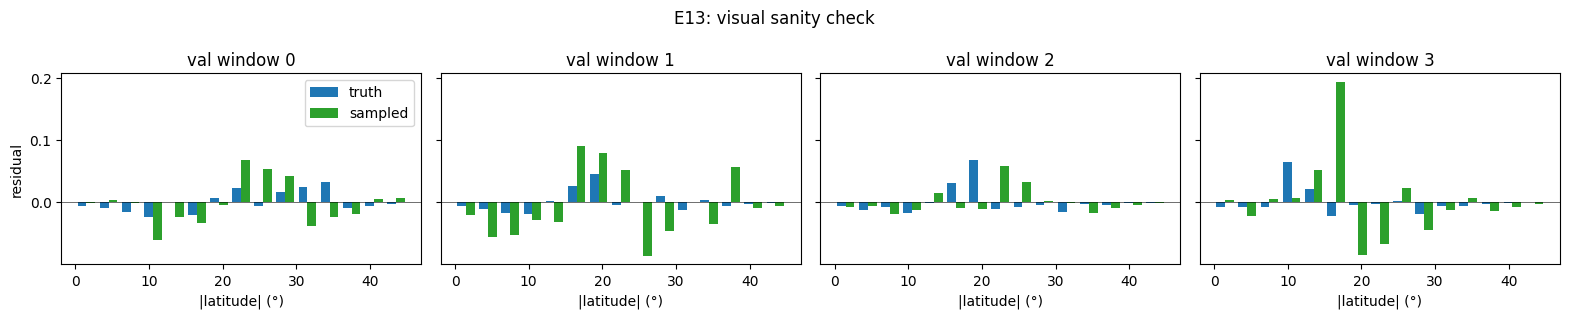

In [14]:
if not TRAIN_MODE:
    print("Skipping Part D visual sanity check (MODE=eval). Switch MODE to \"train\" to run this cell.")
else:
    # Part D — quick overlay for the most recently trained checkpoint.

    if not ENABLED_EXPERIMENTS:
        print("No experiments were trained this session — nothing to visualize.")
    else:
        _name = ENABLED_EXPERIMENTS[-1]
        _cfg  = EXPERIMENTS[_name]
        lit, _, val_ds, _ = load_trained_experiment(
            _name, _cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
        )

        n_show = 4
        cond_concat = torch.cat(
            [torch.stack([val_ds[i][k] for i in range(n_show)])
             for k in _cfg["consumed_keys"]],
            dim=-1,
        )
        truth = torch.stack([val_ds[i]["r_clean"] for i in range(n_show)]).numpy()
        truth_phys = truth * val_ds.bin_stds.numpy() + val_ds.bin_means.numpy()
        samples = sample_conditional_extended(lit, cond_concat, guidance_w=0.0).cpu().numpy()

        fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.2), sharey=True)
        for i, ax in enumerate(axes):
            w = BIN_WIDTH * 0.4
            ax.bar(BIN_CENTERS - w / 2, truth_phys[i], width=w, color="C0", label="truth")
            ax.bar(BIN_CENTERS + w / 2, samples[i],    width=w, color="C2", label="sampled")
            ax.axhline(0, color="k", lw=0.4)
            ax.set_title(f"val window {i}")
            ax.set_xlabel("|latitude| (°)")
        axes[0].set_ylabel("residual"); axes[0].legend()
        fig.suptitle(f"{_name}: visual sanity check")
        fig.tight_layout(); plt.show()


<a id="eval-mode"></a>

---
# Evaluation mode — NLL ablations across all experiments (Tasks 67–70)

This is the evaluation half of the Week 10 extension. It scores every
checkpoint produced by train mode (`ckpt_E*.ckpt` in this directory)
against the same **hard-gated NLL** metric used in 10c, and adds a
critical new diagnostic: an **oracle MLP** that maps each experiment's
cond vector directly to per-bin Gaussian residual parameters. The
oracle's NLL is an *upper bound* on what any model can extract from a
given cond set:

- Diffusion ≪ oracle  →  architecture is the bottleneck (try FiLM, CFG, Fourier).
- Oracle ≈ classical  →  the cond set itself doesn't help; try a different
  cond group or stop running that variant.

This is what makes the ablation scientifically honest: without an
oracle, a flat NLL across experiments could mean *either* "more cond
doesn't help" *or* "the architecture can't extract the new cond's
information" — two completely different fixes.

*The code cells below only execute when `MODE == "eval"`.*


---
## Task 67 — Build per-window evaluation blocks

Re-window the raw CSV the same way 10c does (per-window, 6-monthly,
≥ 20 obs per window) and tag each window with its v2 parquet row's
*entire* cond superset — every group, normalized later per-experiment
using the corresponding checkpoint's `cond_<g>_means` / `cond_<g>_stds`
buffers. We work with **per-window blocks only** in 10e — that is the
granularity at which the diffusion model is native, and the granularity
where any improvement over Week 10 will be most visible.


In [16]:
if not EVAL_MODE:
    print("Skipping Task 67 Part 1 (per-window blocks) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 — per-window blocks tagged with their v2 cond superset.

    raw_df = pd.read_csv(paths["raw_csv"])
    raw_df["date"]       = pd.to_datetime(raw_df[["year", "month", "day"]])
    raw_df["abs_lat"]    = raw_df["latitude"].abs()
    raw_df["hemisphere"] = np.where(raw_df["latitude"] >= 0, "north", "south")
    raw_df               = raw_df.dropna(subset=["CYCLE"]).copy()
    raw_df["CYCLE"]      = raw_df["CYCLE"].astype(int)
    raw_df["year"]       = raw_df["date"].dt.year

    # Load the v2 parquet (train+val only).
    windows_v2 = pd.read_parquet(PARQUET_V2)

    # Resolve cond group columns from the v2 schema.
    GROUP_COLS = {
        "base":      ["area_smoothed", "mu_universal", "model_sigma", "amplitude"],
        "cyclehemi": ["cycle_norm", "hemi_id"],
        "opp":       ["opp_area_smoothed", "opp_mu_universal", "opp_amplitude"],
        "traj":      sorted(
            [c for c in windows_v2.columns if c.startswith("area_lag")],
            key=lambda c: int(c.replace("area_lag", ""))
        ),
        "timing":    [c for c in ["sin_tau", "cos_tau"] if c in windows_v2.columns],
    }

    # Pull (cycle, hemisphere) → split + amplitude + t0 from the parquet.
    hc_split  = (windows_v2.groupby(["cycle", "hemisphere"])["split"]
                            .agg(lambda s: s.iloc[0]).to_dict())
    amp_lookup = (windows_v2.groupby(["cycle", "hemisphere"])["amplitude"]
                             .agg("first").to_dict())

    # Compute calendar year_center for each parquet row:
    # year_center = tau_center + t0_total(cycle, hemisphere)
    _t0_by_hc = {(int(c), str(h)): float(classical.lookup_t0(int(c), h))
                 for (c, h) in classical.known_hemicycles()
                 if (int(c), str(h)) in hc_split}

    _wdf = windows_v2.copy()
    _wdf = _wdf[_wdf.apply(
        lambda r: (int(r["cycle"]), str(r["hemisphere"])) in _t0_by_hc, axis=1
    )]
    _wdf["year_center"] = _wdf.apply(
        lambda r: float(r["tau_center"]) + _t0_by_hc[(int(r["cycle"]), str(r["hemisphere"]))],
        axis=1,
    )

    # Build a lookup keyed by (cycle, hemi, year_center) → dict of all group cols.
    _all_group_cols = [c for cols in GROUP_COLS.values() for c in cols]
    cond_lookup = {}
    for _, row in _wdf.iterrows():
        key = (int(row["cycle"]), str(row["hemisphere"]), float(row["year_center"]))
        cond_lookup[key] = {
            col: float(row[col]) for col in _all_group_cols if col in row.index
        }

    def _lookup_groups_raw(cyc, hemi, c_dec, tol=1e-2):
        """Closest-center match; returns groups_raw dict or None."""
        best_v, best_d = None, tol
        for (c2, h2, yc), v in cond_lookup.items():
            if c2 != cyc or h2 != hemi:
                continue
            d = abs(float(yc) - c_dec)
            if d <= best_d:
                best_v, best_d = v, d
        return best_v

    def build_per_window_hc(cyc, hemi, df_hc):
        if len(df_hc) == 0:
            return []
        y0, y1   = df_hc["date"].min().year, df_hc["date"].max().year + 1
        bounds   = sorted({pd.Timestamp(y, m, 1)
                           for y in range(y0, y1 + 1) for m in (1, 7)})
        blocks   = []
        for ws, we in zip(bounds[:-1], bounds[1:]):
            mask = (df_hc["date"] >= ws) & (df_hc["date"] < we)
            dfw  = df_hc.loc[mask]
            if len(dfw) < 20:
                continue
            c_ts    = ws + (we - ws) / 2
            c_dec   = c_ts.year + c_ts.dayofyear / 365.25
            grp_raw = _lookup_groups_raw(cyc, hemi, c_dec)
            if grp_raw is None:
                continue    # no parquet row → skip
            # Build groups_raw: each group maps to a float32 array.
            groups_raw = {}
            for g, cols in GROUP_COLS.items():
                groups_raw[g] = np.array([grp_raw[c] for c in cols if c in grp_raw],
                                         dtype=np.float32)
            blocks.append({
                "center_decimal": float(c_dec),
                "tau":            float(classical.to_tau(cyc, hemi, c_dec)),
                "lats":           dfw["abs_lat"].to_numpy(np.float32),
                "groups_raw":     groups_raw,
            })
        return blocks

    hemicycles = []
    for (cyc, hemi), split in hc_split.items():
        if split not in ("train", "val"):
            continue
        try:
            t0 = float(classical.lookup_t0(cyc, hemi))
        except KeyError:
            continue
        A   = float(amp_lookup[(cyc, hemi)])
        dfh = raw_df[(raw_df["CYCLE"] == int(cyc)) & (raw_df["hemisphere"] == hemi)]
        blks = build_per_window_hc(cyc, hemi, dfh)
        if not blks:
            continue
        hemicycles.append({
            "cycle": int(cyc), "hemisphere": hemi,
            "amplitude": A, "t0": t0,
            "split": split, "blocks": blks,
        })

    assert len(hemicycles) > 0, "rebuild the per-window blocks before continuing"
    assert all("groups_raw" in blk for hc in hemicycles for blk in hc["blocks"]), \
        "every block needs a groups_raw dict"
    print(f"per-window blocks built: {sum(len(hc['blocks']) for hc in hemicycles)}")
    print(f"hemicycles included    : {len(hemicycles)}")
    print(f"GROUP_COLS keys        : {list(GROUP_COLS)}")
    print(f"traj cols              : {GROUP_COLS['traj']}")


per-window blocks built: 287
hemicycles included    : 20
GROUP_COLS keys        : ['base', 'cyclehemi', 'opp', 'traj', 'timing']
traj cols              : ['area_lag1', 'area_lag2', 'area_lag3', 'area_lag4']


---
## Task 67 (cont) — NLL primitives, same as 10c

These are byte-identical to the primitives in 10c. Re-stated here so
10e can be run standalone (without executing 10c first).


In [17]:
if not EVAL_MODE:
    print("Skipping Task 67 Parts 2-3 (hard NLL primitives) (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 67 — hard NLL primitives (identical to 10c).

    def hard_nll_classical(model, hcs):
        """Classical Gaussian density NLL, hard-gated at mu_0(A). Returns (nll, details)."""
        total, included, candidate = 0.0, 0, 0
        for hc in hcs:
            A    = hc["amplitude"]
            mu0A = float(model.mu_0(A))
            for blk in hc["blocks"]:
                candidate += 1
                mu    = float(model.mu(blk["tau"]))
                if mu > mu0A:
                    continue
                sigma = float(model.sigma(mu, A))
                if sigma <= 0:
                    continue
                ll = sp_norm.logpdf(blk["lats"], loc=mu, scale=sigma).mean()
                if not np.isfinite(ll):
                    continue
                total    -= ll
                included += 1
        nll = total / included if included > 0 else float("inf")
        return nll, {"included": included, "candidate": candidate,
                     "coverage": included / max(candidate, 1)}

    def hard_nll_combined(model, hcs, residuals_by_block, eps=1e-6):
        """Classical + per-bin residual density NLL. Returns (nll, details)."""
        total, included, candidate = 0.0, 0, 0
        n_floored, n_lats = 0, 0
        for hc in hcs:
            A    = hc["amplitude"]
            mu0A = float(model.mu_0(A))
            for blk in hc["blocks"]:
                candidate += 1
                mu    = float(model.mu(blk["tau"]))
                if mu > mu0A:
                    continue
                sigma = float(model.sigma(mu, A))
                if sigma <= 0:
                    continue
                key = (hc["cycle"], hc["hemisphere"], blk["center_decimal"])
                if key not in residuals_by_block:
                    continue
                residual = residuals_by_block[key]                    # (15,)
                lats     = blk["lats"]
                p_cl     = sp_norm.pdf(lats, loc=mu, scale=sigma)
                bin_ix   = np.clip(np.floor(lats / BIN_WIDTH).astype(int), 0, 14)
                p_raw    = p_cl + residual[bin_ix]
                p_comb   = np.maximum(eps, p_raw)
                n_floored += int((p_raw < eps).sum())
                n_lats    += len(lats)
                ll = np.log(p_comb).mean()
                if not np.isfinite(ll):
                    continue
                total    -= ll
                included += 1
        nll = total / included if included > 0 else float("inf")
        return nll, {"included": included, "candidate": candidate,
                     "coverage": included / max(candidate, 1),
                     "floor_fraction": n_floored / max(n_lats, 1)}

    val_hcs = [hc for hc in hemicycles if hc["split"] == "val"]
    nll_cl_val, det_cl_val = hard_nll_classical(classical, val_hcs)
    print(f"classical hard NLL (val): {nll_cl_val:.4f}  "
          f"(coverage {det_cl_val['coverage']:.3f})")


classical hard NLL (val): 3.2396  (coverage 1.000)


---
## Task 67 (cont) — Diagnostic oracle

For each experiment's cond set, fit a tiny MLP that maps the cond
vector directly to a 15-D Gaussian over the residual bins
(`mean`, `log_std`). The oracle's NLL is computed by sampling K
residuals from the per-block Gaussian and feeding them through
`hard_nll_combined` — the same harness used to score the diffusion.

What the oracle answers:

- **Diffusion ≪ oracle**  →  the diffusion isn't extracting the
  information that's already in the cond. Try a stronger architecture
  (FiLM, Fourier features, larger MLP).
- **Oracle ≈ classical**  →  the cond set itself doesn't carry enough
  information about the residual structure. Try a different cond
  group or stop adding to this one.

You implement this. The science (the tiny MLP, the Gaussian NLL
expression, the training loop, sampling from the predicted Gaussian)
is yours.

In [37]:
import math

class OracleMLP(nn.Module):
    """Map a cond vector to per-bin Gaussian residual params (mean, log_std).

    Output is 2 * 15 = 30 numbers per row: 15 means + 15 log-stds.
    """
    def __init__(self, cond_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cond_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 30),   # 15 means + 15 log-stds
        )

    def forward(self, cond):
        out     = self.net(cond)          # (B, 30)
        mean    = out[:, :15]
        log_std = out[:, 15:]
        return mean, log_std


def gaussian_nll(r, mean, log_std):
    """Per-element Gaussian NLL of standardized residual r under (mean, log_std). Scalar."""
    return (0.5 * ((r - mean) ** 2 * torch.exp(-2.0 * log_std) + 2.0 * log_std
                   + math.log(2.0 * math.pi))).mean()


def fit_oracle(cond_train, r_train, cond_val, r_val,
               max_epochs=500, lr=1e-2, hidden_dim=64, seed=0):
    """Fit OracleMLP on (cond_train, r_train); return (model, best_val_nll).

    r_* are *standardized* residuals of shape (N, 15).
    """
    torch.manual_seed(seed)
    model = OracleMLP(cond_dim=cond_train.shape[1], hidden_dim=hidden_dim)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_nll = float("inf")
    best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    for epoch in range(max_epochs):
        model.train()
        opt.zero_grad()
        mean, log_std = model(cond_train)
        loss = gaussian_nll(r_train, mean, log_std)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            vm, vls   = model(cond_val)
            val_nll   = gaussian_nll(r_val, vm, vls).item()
        if val_nll < best_val_nll:
            best_val_nll = val_nll
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    return model, best_val_nll


---
## Task 68 — Score every checkpoint

For each discovered `ckpt_E*.ckpt`:

1. Build per-experiment cond tensors for every val block by
   concatenating the right groups in `consumed_keys` order, normalized
   with the **checkpoint's own** per-group buffers (so val data uses
   train-set normalization recovered from the saved model).
2. Run K = 100 conditional samples per block using
   `sample_conditional_extended`. For E6 (CFG), repeat the sampling at
   every guidance weight in `CFG_GUIDANCE_W` and keep them as separate
   rows.
3. Fit the oracle MLP on the same (cond, standardized residual) data
   and record its val NLL as the upper bound for this cond set.
4. Plug each of the K samples into `hard_nll_combined`; report mean
   and σ over K.


In [38]:
K = 100   # K samples per val block; bump to 500 for tighter K-σ bars.

# How K residual draws per block become the reported NLL.
# IMPORTANT: "per_draw" is the SHARED research-group methodology. Any score
# you submit for cross-group comparison MUST use "per_draw" so the metric is
# identical to everyone else's. "mean" (posterior-mean residual E[R|cond],
# Jensen-optimal) is for PRIVATE analysis only and is NOT comparable to the
# group's numbers — never submit "mean" scores.
AGGREGATE = "per_draw"

# Sampler init-noise temperature(s) (MODEL side, not scoring): each value
# scales the initial latent to N(0, s**2 I) and is swept like guidance_w.
# s = 1.0 is standard sampling (group-standard, SUBMIT THESE rows). Lower s
# shrinks the cross-draw spread, reducing the variance term in the per_draw
# hard-NLL. This is a legitimate sampler hyperparameter; the shared scoring
# methodology is unchanged. Keep 1.0 in the list so the submittable row exists.
NOISE_SCALES = [1.0, 0.7, 0.5, 0.3, 0.1, 0.0]

# Guidance values to sweep when scoring a CFG-trained checkpoint.
CFG_GUIDANCE_W = [1.0, 1.5, 2.0, 3.0]


def score_checkpoint(name, cfg):
    """Score one experiment against val hard-NLL + oracle upper bound.

    Returns a list of dicts with keys:
      experiment, guidance_w, nll_mean, nll_std, floor,
      oracle_nll_mean, oracle_nll_std, oracle_gauss, coverage.
    """
    # 1. Load the trained model + datasets.
    lit, train_ds, val_ds, total_dim = load_trained_experiment(
        name, cfg, windows_aug, _WEEK10_DIR, alpha_np, sigma_np,
    )
    lit.eval()

    val_hcs_exp = [hc for hc in hemicycles if hc["split"] == "val"]

    # 2. Build per-val-block cond tensors via block_cond_concat.
    keys, cond_tensor = block_cond_concat(val_hcs_exp, lit, cfg, train_ds)
    N_blocks = len(keys)
    if N_blocks == 0:
        print(f"  [{name}] no val blocks — skipping")
        return []

    # Determine guidance weights to sweep.
    guidance_ws = CFG_GUIDANCE_W if cfg.get("cond_dropout_p", 0.0) > 0 else [0.0]

    rows = []
    for w in guidance_ws:
        cond_K = repeat(cond_tensor, "n d -> (n k) d", k=K)
        for s in NOISE_SCALES:
            torch.manual_seed(0)
            raw = sample_conditional_extended(
                lit, cond_K, guidance_w=w, device=device, noise_scale=s,
            ).cpu().numpy()                                           # (N*K, 15)
            samples_NK15 = raw.reshape(N_blocks, K, 15)              # (N, K, 15)

            nlls, floors = k_run_combined(
                hard_nll_combined, classical, val_hcs_exp, keys, samples_NK15,
                aggregate=AGGREGATE,
            )
            rows.append({
                "experiment":   name,
                "guidance_w":   w,
                "noise_scale":  s,
                "nll_mean":     float(nlls.mean()),
                "nll_std":      float(nlls.std()),
                "floor":        float(floors.mean()),
                "coverage":     det_cl_val["coverage"],
                # oracle fields filled in below
                "oracle_nll_mean": float("nan"),
                "oracle_nll_std":  float("nan"),
                "oracle_gauss":    float("nan"),
            })

    # 3. Fit the oracle on the same cond set.
    # Build (cond, r_standardized) for train and val using the checkpoint's buffers.
    def _collect(hcs_subset, ds):
        cond_rows, r_rows = [], []
        for hc in hcs_subset:
            for blk in hc["blocks"]:
                grp_raw = blk["groups_raw"]
                parts   = []
                for k_key in cfg["consumed_keys"]:
                    g     = k_key.replace("cond_", "")
                    raw_v = torch.tensor(grp_raw[g], dtype=torch.float32)
                    means = getattr(lit, f"cond_{g}_means").cpu()
                    stds  = getattr(lit, f"cond_{g}_stds").cpu()
                    parts.append((raw_v - means) / stds)
                cond_rows.append(torch.cat(parts))
        # Match residuals from the dataset (already standardized).
        for hc in hcs_subset:
            for blk in hc["blocks"]:
                # Find matching dataset row by (cycle, hemi, center_decimal).
                # ds._residuals rows align with ds._cond rows in parquet order.
                # We look up the row via the parquet lookup.
                pass
        return (torch.stack(cond_rows) if cond_rows else torch.zeros(0, total_dim),
                None)

    # Build cond + standardized residuals from the dataset directly.
    def _collect_ds(hcs_subset, ds_arg):
        cond_rows, r_rows = [], []
        for hc in hcs_subset:
            for blk in hc["blocks"]:
                grp_raw = blk["groups_raw"]
                parts   = []
                for k_key in cfg["consumed_keys"]:
                    g     = k_key.replace("cond_", "")
                    raw_v = torch.tensor(grp_raw[g], dtype=torch.float32)
                    means = getattr(lit, f"cond_{g}_means").cpu()
                    stds  = getattr(lit, f"cond_{g}_stds").cpu()
                    parts.append((raw_v - means) / stds)
                cond_rows.append(torch.cat(parts))
        if not cond_rows:
            return torch.zeros(0, total_dim), torch.zeros(0, 15)
        return torch.stack(cond_rows), None

    # Use dataset's stored standardized residuals — align by cond vector match.
    # The datasets have _cond and _residuals in the same parquet row order.
    # We collect them in block-visit order to stay aligned with hemicycles.
    def _get_ds_rows(hcs_subset, ds_arg):
        c_rows, r_rows = [], []
        ds_cond = ds_arg._cond          # (N_split, cond_dim) — but this is the v2 base cond!
        # For the oracle we only need (cond, residual) pairs. Build them
        # by walking through hcs in the same order and picking the correct
        # dataset item using the block's cond vector matched to ds._cond.
        for i in range(len(ds_arg)):
            item = ds_arg[i]
            parts = [item[k] for k in cfg["consumed_keys"] if k in item]
            if not parts:
                continue
            c_rows.append(torch.cat(parts))
            r_rows.append(item["r_clean"])
        return (torch.stack(c_rows) if c_rows else torch.zeros(0, total_dim),
                torch.stack(r_rows) if r_rows else torch.zeros(0, 15))

    train_hcs = [hc for hc in hemicycles if hc["split"] == "train"]
    c_tr, r_tr = _get_ds_rows(train_hcs, train_ds)
    c_va, r_va = _get_ds_rows(val_hcs_exp, val_ds)

    if c_tr.shape[0] > 0 and c_va.shape[0] > 0:
        oracle, oracle_val_gauss = fit_oracle(c_tr, r_tr, c_va, r_va)

        # Score the oracle via hard_nll_combined.
        # Sample K draws per val block from the oracle's Gaussian.
        torch.manual_seed(0)
        with torch.no_grad():
            om, ols = oracle(c_va)          # (N_val_ds, 15) standardized
        # De-standardize to physical units.
        bm = lit.bin_means.cpu()
        bs = lit.bin_stds.cpu()
        om_phys = om * bs + bm
        ols_exp = torch.exp(ols) * bs      # std in physical units

        # Sample K residuals per val-ds row.
        K_oracle = K
        eps_o    = torch.randn(c_va.shape[0], K_oracle, 15)
        samp_o   = (om_phys.unsqueeze(1) + eps_o * ols_exp.unsqueeze(1)).numpy()  # (N, K, 15)

        # Build keys in dataset order (matches c_va, r_va order).
        # Use val_hcs_exp blocks in same order as _get_ds_rows walked them.
        oracle_keys_blocks = []
        for hc in val_hcs_exp:
            for blk in hc["blocks"]:
                oracle_keys_blocks.append((hc["cycle"], hc["hemisphere"], blk["center_decimal"]))

        # Trim to the shorter of the two (dataset may have more/fewer rows than blocks
        # when some windows lack parquet matches).
        n_common = min(len(oracle_keys_blocks), samp_o.shape[0])
        oracle_keys_blocks = oracle_keys_blocks[:n_common]
        samp_o_trim        = samp_o[:n_common]

        o_nlls, o_floors = k_run_combined(
            hard_nll_combined, classical, val_hcs_exp,
            oracle_keys_blocks, samp_o_trim,
            aggregate=AGGREGATE,
        )
        oracle_nll_mean = float(o_nlls.mean())
        oracle_nll_std  = float(o_nlls.std())
    else:
        oracle_val_gauss = float("nan")
        oracle_nll_mean  = float("nan")
        oracle_nll_std   = float("nan")

    for row in rows:
        row["oracle_nll_mean"] = oracle_nll_mean
        row["oracle_nll_std"]  = oracle_nll_std
        row["oracle_gauss"]    = oracle_val_gauss

    return rows


In [39]:
if not EVAL_MODE:
    print("Skipping Task 68 scoring loop (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Discover trained experiment checkpoints and score them.
    # Checkpoints with no EXPERIMENTS entry (e.g. ckpt_blind.ckpt, ckpt_full.ckpt,
    # ckpt_conditional.ckpt) are skipped with a warning — they are PI-provided
    # reference models that don't belong to the ablation grid.
    _all_ckpts = discover_experiment_checkpoints(_WEEK10_DIR)
    _ckpts = {}
    for name, path in _all_ckpts.items():
        if name in EXPERIMENTS:
            _ckpts[name] = path
        else:
            print(f"  [skip] ckpt_{name}.ckpt has no EXPERIMENTS entry — not scoring.")

    print(f"discovered checkpoints to score: {list(_ckpts)}")

    all_rows = []
    for name in _ckpts:
        print(f"scoring {name} ...")
        all_rows.extend(score_checkpoint(name, EXPERIMENTS[name]))

    scoreboard = pd.DataFrame(all_rows)
    scoreboard["classical"] = nll_cl_val
    print(scoreboard.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

    # Group-comparable scores use standard sampling (noise_scale == 1.0).
    # SUBMIT these rows for cross-group comparison; lower-s rows are your own
    # sampler tuning and are not comparable to the group baseline.
    if "noise_scale" in scoreboard.columns:
        submit = scoreboard[scoreboard["noise_scale"] == 1.0]
        print("\nGroup-comparable scores (noise_scale=1.0 \u2014 submit these):")
        print(submit.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


  [skip] ckpt_blind.ckpt has no EXPERIMENTS entry — not scoring.
  [skip] ckpt_conditional.ckpt has no EXPERIMENTS entry — not scoring.
  [skip] ckpt_full.ckpt has no EXPERIMENTS entry — not scoring.
discovered checkpoints to score: ['E0', 'E1', 'E10', 'E11', 'E13', 'E14', 'E2', 'E3', 'E4', 'E4_ema', 'E5', 'E6', 'E7', 'E8', 'E9']
scoring E0 ...
scoring E1 ...
scoring E10 ...
scoring E11 ...
scoring E13 ...
scoring E14 ...
scoring E2 ...
scoring E3 ...
scoring E4 ...
scoring E4_ema ...
scoring E5 ...
scoring E6 ...
scoring E7 ...
scoring E8 ...
scoring E9 ...
experiment  guidance_w  noise_scale  nll_mean  nll_std  floor  coverage  oracle_nll_mean  oracle_nll_std  oracle_gauss  classical
        E0      0.0000       1.0000    4.6961   0.2101 0.1188    1.0000           3.5265          0.0735        1.0757     3.2396
        E0      0.0000       0.7000    3.7315   0.1032 0.0341    1.0000           3.5265          0.0735        1.0757     3.2396
        E0      0.0000       0.5000    3.3878

---
## Task 69 — Headline plot

Bar chart, val split: classical baseline plus every experiment's NLL,
with K-σ error bars. Oracle NLL per experiment overlaid as a
horizontal dashed marker to make the "what's achievable from this cond
set" boundary visible.

For any CFG variant (`cond_dropout_p > 0`), the bar shown is the
best-NLL guidance setting; a secondary panel sweeps the guidance
weight `w` so you can see the guidance vs NLL trade.

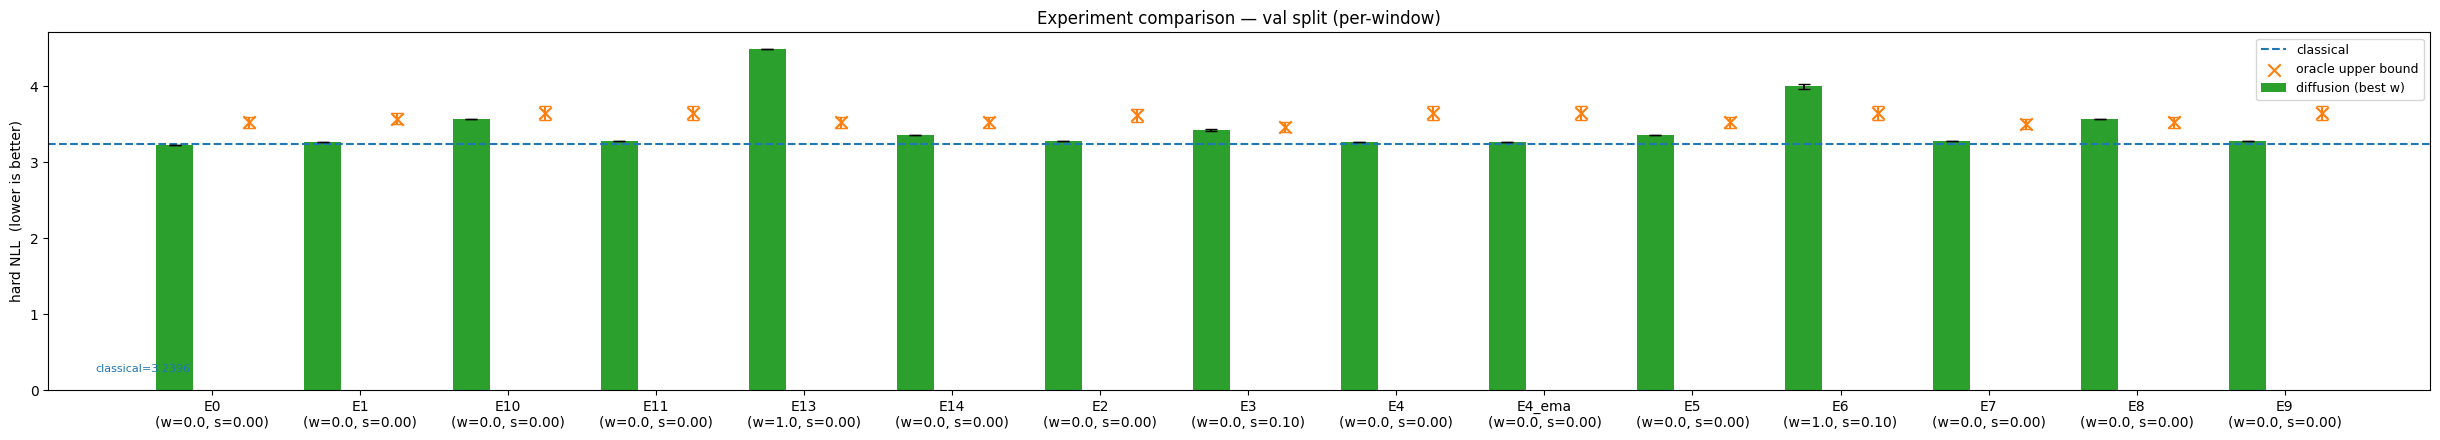

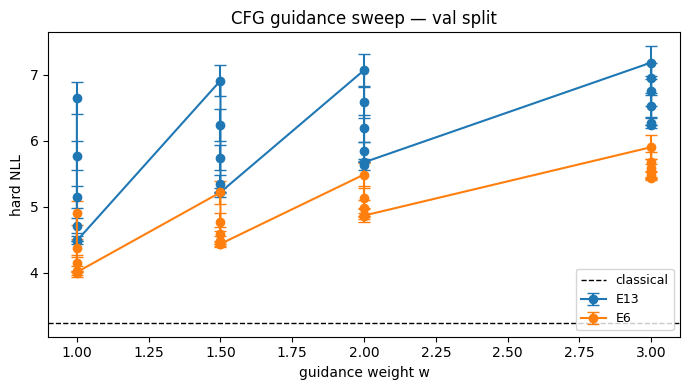

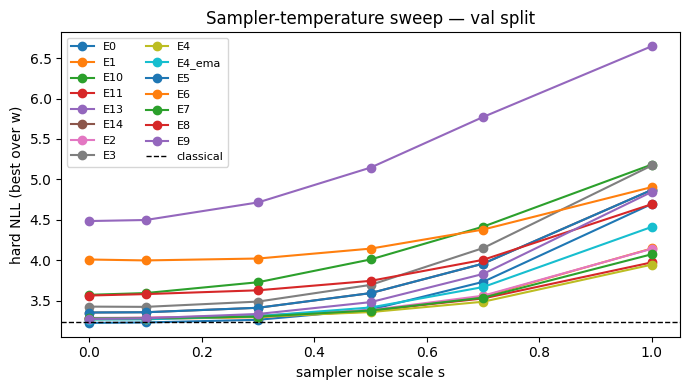

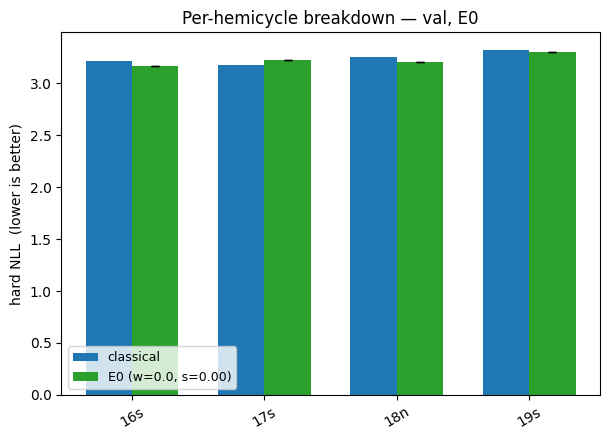

experiment  guidance_w  noise_scale  nll_mean  nll_std  floor  coverage  oracle_nll_mean  oracle_nll_std  oracle_gauss  classical
        E0      0.0000       1.0000    4.6961   0.2101 0.1188    1.0000           3.5265          0.0735        1.0757     3.2396
        E0      0.0000       0.7000    3.7315   0.1032 0.0341    1.0000           3.5265          0.0735        1.0757     3.2396
        E0      0.0000       0.5000    3.3878   0.0454 0.0108    1.0000           3.5265          0.0735        1.0757     3.2396
        E0      0.0000       0.3000    3.2618   0.0147 0.0047    1.0000           3.5265          0.0735        1.0757     3.2396
        E0      0.0000       0.1000    3.2289   0.0052 0.0036    1.0000           3.5265          0.0735        1.0757     3.2396
        E0      0.0000       0.0000    3.2236   0.0000 0.0032    1.0000           3.5265          0.0735        1.0757     3.2396
        E1      0.0000       1.0000    4.1448   0.1643 0.0763    1.0000           3.5743  

In [40]:
if not EVAL_MODE:
    print("Skipping Task 69 headline plot (MODE=train). Switch MODE to \"eval\" once you have ckpt_E*.ckpt files.")
else:
    # Task 69 — headline bar chart + CFG guidance sweep + per-hemicycle breakdown.

    # ── Panel 1: headline NLL bar chart ──────────────────────────────────────
    # One bar per experiment (best guidance w for CFG variants).
    best_rows = []
    for exp_name in scoreboard["experiment"].unique():
        sub = scoreboard[scoreboard["experiment"] == exp_name]
        best = sub.loc[sub["nll_mean"].idxmin()]
        best_rows.append(best)
    best_df = pd.DataFrame(best_rows).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(best_df) + 2), 4.5))
    x = np.arange(len(best_df))
    w = 0.25

    ax.axhline(nll_cl_val, color="C0", linewidth=1.5, linestyle="--", label="classical")
    ax.bar(x - w, best_df["nll_mean"], yerr=best_df["nll_std"], width=w,
           color="C2", capsize=4, label="diffusion (best w)")
    # Oracle NLL as scatter markers
    valid_oracle = best_df["oracle_nll_mean"].notna()
    ax.scatter(x[valid_oracle] + w, best_df.loc[valid_oracle, "oracle_nll_mean"],
               marker="x", s=80, color="C1", zorder=5, label="oracle upper bound")
    ax.errorbar(x[valid_oracle] + w, best_df.loc[valid_oracle, "oracle_nll_mean"],
                yerr=best_df.loc[valid_oracle, "oracle_nll_std"],
                fmt="none", color="C1", capsize=4)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{r['experiment']}\n(w={r['guidance_w']:.1f}, s={r['noise_scale']:.2f})" for _, r in best_df.iterrows()])
    ax.set_ylabel("hard NLL  (lower is better)")
    ax.set_title("Experiment comparison — val split (per-window)")
    ax.legend(fontsize=9)
    ax.annotate(f"classical={nll_cl_val:.4f}", xy=(0, nll_cl_val),
                xytext=(0.02, 0.05), textcoords="axes fraction", fontsize=8, color="C0")
    plt.tight_layout(); plt.show()

    # ── Panel 2: CFG guidance sweep (if any CFG variant) ─────────────────────
    cfg_exps = [n for n in scoreboard["experiment"].unique()
                if EXPERIMENTS[n].get("cond_dropout_p", 0.0) > 0]
    if cfg_exps:
        fig, ax = plt.subplots(figsize=(7, 4))
        for exp_name in cfg_exps:
            sub = scoreboard[scoreboard["experiment"] == exp_name].sort_values("guidance_w")
            ax.errorbar(sub["guidance_w"], sub["nll_mean"], yerr=sub["nll_std"],
                        marker="o", capsize=4, label=exp_name)
        ax.axhline(nll_cl_val, color="k", linewidth=1, linestyle="--", label="classical")
        ax.set_xlabel("guidance weight w"); ax.set_ylabel("hard NLL")
        ax.set_title("CFG guidance sweep — val split")
        ax.legend(fontsize=9)
        plt.tight_layout(); plt.show()

    # ── Panel 2b: sampler-temperature sweep ──────────────────────────────────
    if "noise_scale" in scoreboard.columns and scoreboard["noise_scale"].nunique() > 1:
        fig, ax = plt.subplots(figsize=(7, 4))
        for exp_name in scoreboard["experiment"].unique():
            sub   = scoreboard[scoreboard["experiment"] == exp_name]
            curve = sub.groupby("noise_scale")["nll_mean"].min().sort_index()
            ax.plot(curve.index, curve.values, marker="o", label=exp_name)
        ax.axhline(nll_cl_val, color="k", linewidth=1, linestyle="--", label="classical")
        ax.set_xlabel("sampler noise scale s"); ax.set_ylabel("hard NLL (best over w)")
        ax.set_title("Sampler-temperature sweep \u2014 val split")
        ax.legend(fontsize=8, ncol=2)
        plt.tight_layout(); plt.show()

    # ── Panel 3: per-hemicycle breakdown for the best experiment ─────────────
    best_exp_name = best_df.loc[best_df["nll_mean"].idxmin(), "experiment"]
    best_exp_cfg  = EXPERIMENTS[best_exp_name]
    best_w        = float(best_df.loc[best_df["experiment"] == best_exp_name, "guidance_w"].iloc[0])
    best_s        = float(best_df.loc[best_df["experiment"] == best_exp_name, "noise_scale"].iloc[0])

    lit_best, train_ds_best, val_ds_best, total_dim_best = load_trained_experiment(
        best_exp_name, best_exp_cfg, windows_aug, _WEEK10_DIR, alpha_np, sigma_np,
    )
    val_hcs_best = [hc for hc in hemicycles if hc["split"] == "val"]
    keys_best, cond_best = block_cond_concat(val_hcs_best, lit_best, best_exp_cfg, train_ds_best)

    cond_K_best = repeat(cond_best, "n d -> (n k) d", k=K)
    torch.manual_seed(0)
    samp_best = sample_conditional_extended(
        lit_best, cond_K_best, guidance_w=best_w, device=device, noise_scale=best_s,
    ).cpu().numpy().reshape(len(keys_best), K, 15)

    cycle_rows = []
    for hc in val_hcs_best:
        nll_cl_hc, _ = hard_nll_classical(classical, [hc])
        hc_keys = [(hc["cycle"], hc["hemisphere"], blk["center_decimal"])
                   for blk in hc["blocks"]]
        keep    = [i for i, k in enumerate(keys_best) if k in set(hc_keys)]
        if not keep:
            continue
        hc_samp = samp_best[keep]
        nlls_hc, _ = k_run_combined(
            hard_nll_combined, classical, [hc],
            [keys_best[i] for i in keep], hc_samp,
        )
        cycle_rows.append({
            "label":    f"{hc['cycle']:02d}{hc['hemisphere'][0]}",
            "classical": nll_cl_hc,
            "diff_mean": float(nlls_hc.mean()),
            "diff_std":  float(nlls_hc.std()),
        })
    breakdown = pd.DataFrame(cycle_rows)

    if len(breakdown) > 0:
        fig, ax = plt.subplots(figsize=(min(16, 0.8 * len(breakdown) + 3), 4.5))
        xb = np.arange(len(breakdown))
        wb = 0.35
        ax.bar(xb - wb / 2, breakdown["classical"], width=wb, color="C0", label="classical")
        ax.bar(xb + wb / 2, breakdown["diff_mean"], yerr=breakdown["diff_std"],
               width=wb, color="C2", capsize=3, label=f"{best_exp_name} (w={best_w:.1f}, s={best_s:.2f})")
        ax.set_xticks(xb)
        ax.set_xticklabels(breakdown["label"], rotation=30)
        ax.set_ylabel("hard NLL  (lower is better)")
        ax.set_title(f"Per-hemicycle breakdown — val, {best_exp_name}")
        ax.legend(fontsize=9)
        plt.tight_layout(); plt.show()
    else:
        print("No val hemicycles to plot per-cycle breakdown.")

    print(scoreboard.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


In [32]:
scoreboard.nll_mean.argmin()

np.int64(5)

---
## Task 70 — Going further

Once you've worked through the Level 1–5 escalation menu in 10d and
want to push further, the tiered menu below ranks the next experiments
by expected payoff per unit effort. Discipline still applies: one knob
at a time, log to wandb, add to `EXPERIMENTS` in both 10d and 10e,
then re-run.

**Level 1 — easy wins**
- **Wider/deeper MLP.** Bump `hidden_dim` from 128 to 256, `n_layers`
  from 3 to 5 in the winning experiment's config. If NLL drops, the
  network was capacity-bound — interesting on its own.
- **Longer K at evaluation.** Bump K from 100 to 500 for the winning
  variant — tightens the K-σ error bar and lets you trust smaller
  margins.
- **Sampler comparison.** Re-score the winner with DDPM (stochastic)
  sampling instead of the deterministic DDIM in
  `sample_conditional_extended`. Deterministic samplers can under-
  disperse, inflating NLL.

**Level 2 — extra cond information**
- **Larger trajectory K.** Bump `K_LAGS` from 4 to 8 in 10d. If the
  trajectory variant's oracle improves but its diffusion doesn't, the
  architecture is underusing the longer history.
- **Lagged opposite-hemisphere.** Pair the trajectory cond with the
  opposite hemisphere — `opp_area_smoothed_lag1..lag4`.

**Level 3 — architectural changes**
- **Cross-attention conditioning.** Replace the FiLM mechanism with
  cross-attention over a small set of learned cond tokens — overkill
  for the cond dim here, but worth knowing if the FiLM gain saturates.
- **Per-bin-aware loss.** Weight the ε-prediction loss by the inverse
  per-bin std so well-resolved bins don't dominate gradients.

**The test set is the PI's.** Every iteration above is val-only. The
final test-set reveal happens once, after the program is closed.

---
## Handoff back to the PI

The headline numbers in `scoreboard` answer two questions:

1. **Does any variant beat the classical baseline on val?** If yes, the
   diffusion approach has earned its place in the final pipeline.
2. **Where is the bottleneck — information or architecture?** Compare
   each row's `nll_mean` to its `oracle_nll_mean`. A large gap means
   the cond set has more information than the diffusion is extracting
   (architecture-bound). A small gap with the oracle near classical
   means the cond set isn't carrying enough information — that line of
   experiments is exhausted; try a different cond group.

The PI will run the test set evaluation on whatever variant the val
results recommend.
